## 가설 설정
### 1.성별(Gender)에 따른 가설
- H0 : 고객의 성별은 Info 쿠폰의 최종 결제 전환율에 영향을 주지 않는다.
- H1 : 고객의 성별에 따라 Info 쿠폰의 최종 결제 전환율에 유의미한 차이가 있다.

### 2.나이(Age)에 따른 가설
- H0 : 연령대는 Info 쿠폰 전환율에 영향을 주지 않는다.
- H1 : 연령대는 Info 쿠폰 전환율에 유의미한 차이가 있다.

### 3.소득수준(Income)에 따른 가설
- H0 : 소득 수준은 Info 쿠폰에 대한 전환율과 관계가 없다.
- H1 : 소득 수준은 Info 쿠폰 전환율에 유의미한 영향을 미친다.

In [10]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import pingouin as pg
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import scikit_posthocs as sp
import matplotlib.pyplot as plt 
import seaborn as sns
import platform

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("=" * 60)

info_demo = pd.read_csv('../data/info_demo.csv')
all_merge_df = pd.read_csv('../data/all_merged.csv')



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [11]:
info_demo

,person,offer_id,offer_cycle,duration,offer received,offer viewed,expire_time,age,gender,income,age_group,income_group,is_viewed,is_converted
0,0009655768c64bdeb2e877511632db8f,informational_0_0_3,1,3.0,168.0,192.0,240.0,33.0,M,72000.0,30대,6만~8만,1,1
1,0009655768c64bdeb2e877511632db8f,informational_0_0_4,1,4.0,336.0,372.0,432.0,33.0,M,72000.0,30대,6만~8만,1,1
2,0011e0d4e6b944f998e987f904e8c1e5,informational_0_0_3,1,3.0,336.0,354.0,408.0,40.0,O,57000.0,40대,4만~6만,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,informational_0_0_4,1,4.0,0.0,6.0,96.0,40.0,O,57000.0,40대,4만~6만,1,0
4,0020c2b971eb4e9188eac86d93036a77,informational_0_0_3,1,3.0,504.0,660.0,576.0,59.0,F,90000.0,50대,8만~10만,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15230,fff0f0aac6c547b9b263080f09a5586a,informational_0_0_4,2,4.0,576.0,636.0,672.0,67.0,M,80000.0,60대,6만~8만,1,1
15231,fff3ba4757bd42088c044ca26d73817a,informational_0_0_3,1,3.0,336.0,NaN,408.0,69.0,F,83000.0,60대,8만~10만,0,0
15232,fff3ba4757bd42088c044ca26d73817a,informational_0_0_3,2,3.0,504.0,540.0,576.0,69.0,F,83000.0,60대,8만~10만,1,1
15233,fff8957ea8b240a6b5e634b6ee8eafcf,informational_0_0_4,1,4.0,504.0,NaN,600.0,71.0,M,56000.0,70대 이상,4만~6만,0,0


In [12]:
# 성별에 따른 가설 검정 시작

target_gender_df = info_demo[info_demo['gender'].isin(['M', 'F'])] # M과 F만 

contingency_table_gender = pd.crosstab(target_gender_df['gender'], target_gender_df['is_converted']) 
# is_converted(0) : 구매까지 이어지지 못함. is_converted(1) : 구매까지 이어짐. 
print("[성별 교차표]")
display(contingency_table_gender)

# 카이제곱 검정
chi2_gender, p_val_gender, dof_gender, expected_gender = chi2_contingency(contingency_table_gender)
print(f"카이제곱 통계량 : {chi2_gender:.4f}")
print(f"p-value: {p_val_gender:.4f}")
print(f"자유도: {dof_gender}")
print('\n')

# 최종 결론
if p_val_gender < 0.05:
    print(f"결론 : p-value({p_val_gender:.4f})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 성별에 따라 Informational 쿠폰 전환율에 통계적으로 유의미한 차이가 있다.")
else:
    print(f"결론 : p-value({p_val_gender:.4f})가 0.05 이상이므로 귀무가설을 기각하지 못한다")
    print("해석: 성별에 따른 Informational 쿠폰 전환율이 통계적으로 유의미하지 않다.")

[성별 교차표]


is_converted,0,1
gender,,
F,3401,2137
M,4536,3031


카이제곱 통계량 : 2.8224
p-value: 0.0930
자유도: 1


결론 : p-value(0.0930)가 0.05 이상이므로 귀무가설을 기각하지 못한다
해석: 성별에 따른 Informational 쿠폰 전환율이 통계적으로 유의미하지 않다.


In [13]:
# 연령대별 가설 검정 시작

target_age_df = info_demo[info_demo['age_group'] != 'Unknown']

contingency_table_age = pd.crosstab(target_age_df['age_group'], target_age_df['is_converted'])
# is_converted(0) : 구매까지 이어지지 못함. is_converted(1) : 구매까지 이어짐. 
print("[연령대별 교차표]")
display(contingency_table_age)

# 카이제곱 검정
chi2_age, p_val_age, dof_age, expected_age = chi2_contingency(contingency_table_age)
print(f"카이제곱 통계량 : {chi2_age:.4f}")
print(f"p-value: {p_val_age:.4e}")
print(f"자유도: {dof_age}")
print('\n')

# 최종 결론
if p_val_age < 0.05:
    print(f"결론 : p-value({p_val_age:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 연령대에 따라 Informational 쿠폰 전환율에 통계적으로 유의미한 차이가 있다.")
else:
    print(f"결론 : p-value({p_val_age:.4e})가 0.05 이상이므로 귀무가설을 기각하지 못한다")
    print("해석: 연령대에 따른 Informational 쿠폰 전환율이 통계적으로 유의미하지 않다.")


# 효과크기(Cramer's V)
print("="*80)
print("[효과크기 (Cramer's V)]")
v_score = association(contingency_table_age.values, method='cramer')
print(f"소득수준 전환율 차이의 효과 크기 : {v_score:.4f}")


if v_score < 0.10:
    print(f" 해석 : 효과크기가 'small' 미만이다. (통계적으로 유의미하나 실질적 차이는 매우 미미)")
elif v_score < 0.30:
    print(f" 해석 : 효과크기가 'small' (작은 연관성)")
elif v_score < 0.50:
    print(f" 해석 : 효과크기가 'Medium' (중간 수준의 연관성)")
else:
    print(f" 해석 : 효과크기가 'Large' (큰 연관성)")
    

# 조정된 잔차 분석
print("="*80)
print("[조정된 잔차 분석]")
observed = contingency_table_age.values
N = observed.sum()
row_sums = observed.sum(axis=1, keepdims=True) # R_i
col_sums = observed.sum(axis=0, keepdims=True) # C_j
adjusted_residuals = (observed - expected_age) / np.sqrt(expected_age * (1 - row_sums / N) * (1 - col_sums / N))

# 출력
adj_res_df = pd.DataFrame(
    adjusted_residuals,
    index=contingency_table_age.index,
    columns=contingency_table_age.columns
)
display(adj_res_df)


[연령대별 교차표]


is_converted,0,1
age_group,,
10대 이하,109,90
20대,698,479
30대,767,611
40대,1199,848
50대,1943,1259
60대,1678,965
70대 이상,1654,1000


카이제곱 통계량 : 33.7271
p-value: 7.5948e-06
자유도: 6


결론 : p-value(7.5948e-06)가 0.05보다 작으므로 귀무가설 기각
해석: 연령대에 따라 Informational 쿠폰 전환율에 통계적으로 유의미한 차이가 있다.
[효과크기 (Cramer's V)]
소득수준 전환율 차이의 효과 크기 : 0.0504
 해석 : 효과크기가 'small' 미만이다. (통계적으로 유의미하나 실질적 차이는 매우 미미)
[조정된 잔차 분석]


is_converted,0,1
age_group,,
10대 이하,-1.668250,1.668250
20대,-0.887991,0.887991
30대,-3.890842,3.890842
40대,-1.949822,1.949822
50대,0.225244,-0.225244
60대,3.497902,-3.497902
70대 이상,2.131798,-2.131798


### 조정된 잔차 분석 해석
- is_converted = 1 열만 보면 됨!
- 잔차가 -2보다 작은 그룹 : 기대보다 결제를 하지 않는다. => 단순 알림을 보낼 필요가 없음
- 잔차가 +2보다 큰 그룹 : 기대보다 결제까지 잘 이어지는 타겟층 => 알림 핵심 타겟층
- 잔차가 -2 ~ +2 그룹 : 평범

# 최종 인사이트
- 연령대 전환 여부에 통계적으로 유의한 영향을 미치지만, 전체적인 영향력 자체는 미미하다.
- 30-40대를 핵심 타겟으로 잡고, 20대의 결제율이 기대보다 낮기 때문에 젊은 층이 프로모션에 반응하게끔 하는 방안을 생각하는 것이 좋을 것 같다.

In [14]:
# 수익별 가설 검정 시작

target_income_df = info_demo[info_demo['income_group'] != 'Unknown']

contingency_table_income = pd.crosstab(target_income_df['income_group'], target_income_df['is_converted'])
# is_converted(0) : 구매까지 이어지지 못함. is_converted(1) : 구매까지 이어짐. 
print("[소득수준별 교차표]")
display(contingency_table_income)

# 카이제곱 검정
chi2_income, p_val_income, dof_income, expected_income = chi2_contingency(contingency_table_income)
print(f"카이제곱 통계량 : {chi2_income:.4f}")
print(f"p-value: {p_val_income:.4e}")
print(f"자유도: {dof_income}")

# 최종 결론
if p_val_income < 0.05:
    print(f"결론 : p-value({p_val_income:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 소득수준에 따라 Informational 쿠폰 전환율에 통계적으로 유의미한 차이가 있다.")
else:
    print(f"결론 : p-value({p_val_income:.4e})가 0.05 이상이므로 귀무가설을 기각하지 못한다")
    print("해석: 소득수준에 따른 Informational 쿠폰 전환율이 통계적으로 유의미하지 않다.")

# 효과크기(Cramer's V)
print("="*80)
print("[효과크기 (Cramer's V)]")
v_score = association(contingency_table_income.values, method='cramer')
print(f"소득수준 전환율 차이의 효과 크기 : {v_score:.4f}")


if v_score < 0.10:
    print(f" 해석 : 효과크기가 'small' 미만이다. (통계적으로 유의미하나 실질적 차이는 매우 미미)")
elif v_score < 0.30:
    print(f" 해석 : 효과크기가 'small' (작은 연관성)")
elif v_score < 0.50:
    print(f" 해석 : 효과크기가 'Medium' (중간 수준의 연관성)")
else:
    print(f" 해석 : 효과크기가 'Large' (큰 연관성)")
    

# 조정된 잔차 분석
print("="*80)
print("[조정된 잔차 분석]")
observed = contingency_table_income.values
N = observed.sum()
row_sums = observed.sum(axis=1, keepdims=True) # R_i
col_sums = observed.sum(axis=0, keepdims=True) # C_j
adjusted_residuals = (observed - expected_income) / np.sqrt(expected_income * (1 - row_sums / N) * (1 - col_sums / N))

# 출력
adj_res_df = pd.DataFrame(
    adjusted_residuals,
    index=contingency_table_income.index,
    columns=contingency_table_income.columns
)
display(adj_res_df)

[소득수준별 교차표]


is_converted,0,1
income_group,,
10만 이상,694,195
4만 미만,1100,779
4만~6만,2376,1789
6만~8만,2390,1683
8만~10만,1488,806


카이제곱 통계량 : 162.5306
p-value: 4.1893e-34
자유도: 4
결론 : p-value(4.1893e-34)가 0.05보다 작으므로 귀무가설 기각
해석: 소득수준에 따라 Informational 쿠폰 전환율에 통계적으로 유의미한 차이가 있다.
[효과크기 (Cramer's V)]
소득수준 전환율 차이의 효과 크기 : 0.1105
 해석 : 효과크기가 'small' (작은 연관성)
[조정된 잔차 분석]


is_converted,0,1
income_group,,
10만 이상,11.083931,-11.083931
4만 미만,-1.884684,1.884684
4만~6만,-5.518993,5.518993
6만~8만,-2.871867,2.871867
8만~10만,4.689216,-4.689216


### 조정된 잔차 분석 해석
- is_converted = 1 열만 보면 됨!
- 잔차가 -2보다 작은 그룹 : 기대보다 결제를 하지 않는다. => 단순 알림을 보낼 필요가 없음
- 잔차가 +2보다 큰 그룹 : 기대보다 결제까지 잘 이어지는 타겟층 => 알림 핵심 타겟층
- 잔차가 -2 ~ +2 그룹 : 평범

# 최종 인사이트
- 소득수준이 전환 여부에 통계적으로 유의한 영향을 미치지만, 전체적인 영향력 자체는 크지 않다.
- 소득수준이 4만~8만인 사람들을 핵심 타겟으로 잡고, 오히려 소득 수준이 8만을 넘는 사람들의 결제율이 낮기 때문에 이들의 결제를 유도하기 위한 마케팅을 고려해볼 필요성이 있다.

| 조정된 잔차 값   | 해석                                              |
|------------------|---------------------------------------------------|
| \|잔차\| > 2     | 해당 범주/셀이 기대빈도와 유의하게 다릅니다        |
| \|잔차\| ≤ 2     | 해당 범주/셀은 기대빈도와 유의한 차이가 없습니다   |
| 잔차 > 0 (양수)  | 기대보다 **많이** 관측됨                           |
| 잔차 < 0 (음수)  | 기대보다 **적게** 관측됨                           |

**실무 팁**: 
- 범주형에서는 Cramér's V보다 **조정된 잔차 분석**(어느 셀이 기대와 다른가)이 실질적으로 더 중요합니다.

Next Step)
전환율말고 금액으로! (profit or amount) 어차피 Info라 profit이 amount임.

### [성별, 연령대, 소득 수준]에 따른 **평균 결제 금액**이 통계적으로 유의미하게 다른지를 확인해보자.

## 가설 설정
### 1.성별(Gender)에 따른 가설
- H0 : 남성과 여성의 평균 결제 금액에는 유의미한 차이가 없을 것이다.
- H1 : 남성과 여성의 평균 결제 금액에는 유의미한 차이가 있을 것이다.

### 2.나이(Age)에 따른 가설
- H0 : 연령대에 따른 평균 결제 금액에는 유의미한 차이가 없을 것이다.
- H1 : 연령대에 따른 평균 결제 금액에는 유의미한 차이가 있을 것이다.

### 3.소득수준(Income)에 따른 가설
- H0 : 소득 수준별로 평균 결제 금액에 유의미한 차이가 없을 것이다.
- H1 : 소득 수준별로 평균 결제 금액에 유의미한 차이가 있을 것이다.

In [15]:
# info_demo에는 amount가 없음 amount를 붙여야함
# 데이터프레임 준비

# all_merge_df에서 transaction 기록만 뽑기
trans_df = all_merge_df[all_merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# info_demo와 left join (person을 기준으로 time, amount 붙음)
# 구매한 사람들만(is_converted == 1)
merged_for_amount = pd.merge(
    info_demo[info_demo['is_converted'] == 1], 
    trans_df, 
    on='person', 
    how='left'
)

# received에서 expire_time(유효기간) 사이에 있는 결제만 남기기
valid_amounts = merged_for_amount[
    (merged_for_amount['time'] >= merged_for_amount['offer received']) & 
    (merged_for_amount['time'] <= merged_for_amount['expire_time'])
]

# 쿠폰 1장당 여러번 결제 했을 수도 있음. (더블카운팅도 생각해야함)
# 동일한 고객이 동일한 시간에 결제한 동일한 금액은 1건으로 친다.(더블 카운팅 해결)
# => 어차피 우리 목표는 각 쿠폰 중 누가 돈을 더 벌어왔나를 보는게 아니라, info 쿠폰을 각 집단 중 어느 집단이 돈을 더썼냐!임.
unique_transactions = valid_amounts.drop_duplicates(subset=['person', 'time', 'amount'])

# 1명당 Informational 쿠폰 기간 내 결제한 총 금액(amount)
person_amount_df = unique_transactions.groupby('person')['amount'].sum().reset_index()

# gender, income_group
customer_info = info_demo[['person', 'gender', 'age_group', 'income_group']].drop_duplicates()
final_paid_df = pd.merge(person_amount_df, customer_info, on='person', how='left')

final_paid_df

,person,amount,gender,age_group,income_group
0,0009655768c64bdeb2e877511632db8f,30.73,M,30대,6만~8만
1,0020ccbbb6d84e358d3414a3ff76cffd,58.87,F,20대,4만~6만
2,003d66b6608740288d6cc97a6903f4f0,14.78,F,20대,6만~8만
3,00426fe3ffde4c6b9cb9ad6d077a13ea,25.92,F,10대 이하,6만~8만
4,0056df74b63b4298809f0b375a304cf4,58.80,M,50대,8만~10만
...,...,...,...,...,...
4975,ffb7fc8ad0594248a49e210ff0217c2d,25.09,F,50대,10만 이상
4976,ffeaa02452ef451082a0361c3ca62ef5,45.59,F,60대,6만~8만
4977,fff0f0aac6c547b9b263080f09a5586a,47.50,M,60대,6만~8만
4978,fff3ba4757bd42088c044ca26d73817a,432.14,F,60대,8만~10만


남성 인원 수 : 2548명 / 평균 결제액 : $27.40
여성 인원 수 : 1780명 / 평균 결제액 : $38.31
[정규성 검정(Shapiro-Wilk)]
 - 남성 p-value : 2.8434e-66
결론 : p-value(2.8434e-66)가 0.05보다 작으므로 귀무가설 기각
해석: 남성의 결제 금액은 정규분포를 따르지 않는다.

 - 여성 p-value : 9.8951e-58
결론 : p-value(9.8951e-58)가 0.05보다 작으므로 귀무가설 기각
해석: 여성의 결제 금액은 정규분포를 따르지 않는다.
[데이터 분포 시각화: Histogram & Q-Q Plot]


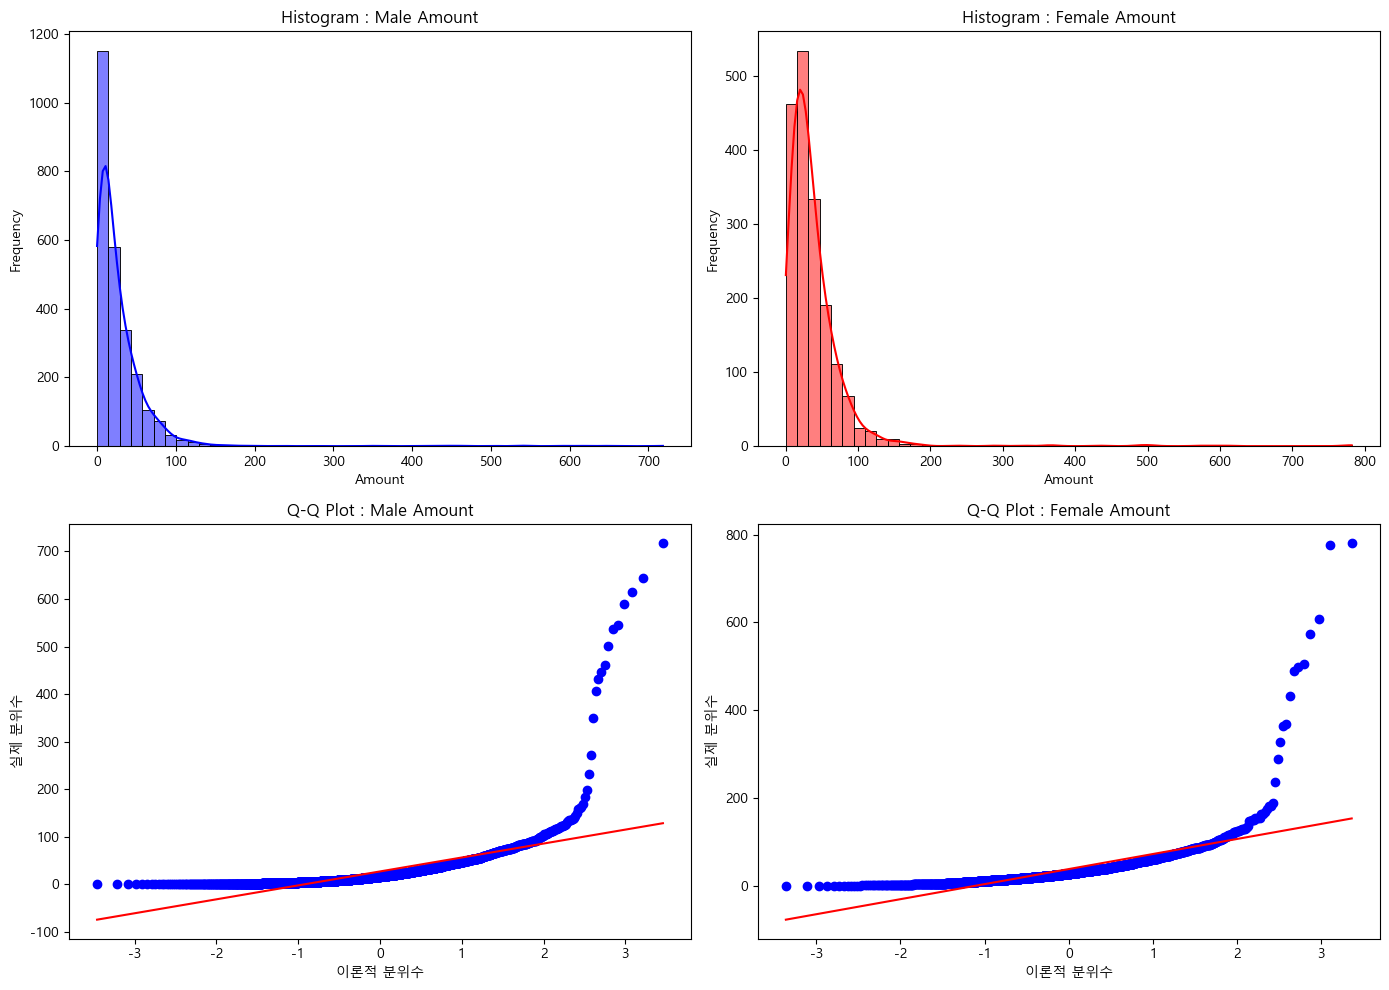

[가설검정] Mann-Whitney U 검정 (비모수 검정)
검정 통계량 (U) : 1642884.5000
p-value : 7.8674e-54
결론: p-value(7.8674e-54)가 0.05보다 작으므로 귀무가설 기각
해석: 남성과 여성의 평균 결제 금액에는 통계적으로 유의미한 차이가 있다.
[효과크기] (rank-biserial r)
효과크기(r) : -0.2755
효과크기 수준은 Small (작은 차이)


In [16]:
# 성별에 따른 평균 결제 금액 비교

# 남성과 여성의 amount만 추출
male_amount = final_paid_df[final_paid_df['gender'] == 'M']['amount'].dropna()
female_amount = final_paid_df[final_paid_df['gender'] == 'F']['amount'].dropna()

print(f"남성 인원 수 : {len(male_amount)}명 / 평균 결제액 : ${male_amount.mean():.2f}")
print(f"여성 인원 수 : {len(female_amount)}명 / 평균 결제액 : ${female_amount.mean():.2f}")

# 정규성 검정(Shapiro-Wilk)
stat_m, p_norm_m = stats.shapiro(male_amount)
stat_f, p_norm_f = stats.shapiro(female_amount)

print("="*80)
print("[정규성 검정(Shapiro-Wilk)]")

print(f" - 남성 p-value : {p_norm_m:.4e}")
if p_norm_m < 0.05 :
    print(f"결론 : p-value({p_norm_m:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 남성의 결제 금액은 정규분포를 따르지 않는다.\n")

print(f" - 여성 p-value : {p_norm_f:.4e}")
if p_norm_f < 0.05 :
    print(f"결론 : p-value({p_norm_f:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 여성의 결제 금액은 정규분포를 따르지 않는다.")


# 시각화 (Q-Q Plot, 히스토그램)

print("="*80)
print("[데이터 분포 시각화: Histogram & Q-Q Plot]")
plt.figure(figsize=(14, 10)) # 그래프 사이즈를 위아래로 키움

# 1. 남성 히스토그램
plt.subplot(2, 2, 1)
sns.histplot(male_amount, kde=True, color='blue', bins=50)
plt.title("Histogram : Male Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# 2. 여성 히스토그램
plt.subplot(2, 2, 2)
sns.histplot(female_amount, kde=True, color='red', bins=50)
plt.title("Histogram : Female Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# 3. 남성 Q-Q Plot
plt.subplot(2, 2, 3)
stats.probplot(male_amount, dist="norm", plot=plt)
plt.title("Q-Q Plot : Male Amount")
plt.xlabel("이론적 분위수")
plt.ylabel("실제 분위수")

# 4. 여성 Q-Q Plot
plt.subplot(2, 2, 4)
stats.probplot(female_amount, dist="norm", plot=plt)
plt.title("Q-Q Plot : Female Amount")
plt.xlabel("이론적 분위수")
plt.ylabel("실제 분위수")

plt.tight_layout()
plt.show()
# => 우측 꼬리가 긴(Right-skewed) 비대칭 데이터


# Mann-WhineyU 검정
print("="*80)
print("[가설검정] Mann-Whitney U 검정 (비모수 검정)")

stat_u, p_val_u = stats.mannwhitneyu(male_amount, female_amount, alternative='two-sided')
print(f"검정 통계량 (U) : {stat_u:.4f}")
print(f"p-value : {p_val_u:.4e}")
if p_val_u < 0.05:
    print(f"결론: p-value({p_val_u:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 남성과 여성의 평균 결제 금액에는 통계적으로 유의미한 차이가 있다.")
else:
    print(f"결론: p-value({p_val_u:.4e})가 0.05이상이므로 귀무가설 기각 실패")
    print("해석: 남성과 여성의 평균 결제 금액 차이는 통계적으로 유의미하지 않다")

# 효과크기 (rank-biserial r)
print("="*80)
print(f"[효과크기] (rank-biserial r)")
eff_size = pg.mwu(male_amount, female_amount)['RBC'].values[0]
print(f"효과크기(r) : {eff_size:.4f}")

if abs(eff_size) < 0.1:
    print("효과크기 수준은 Very Small (실질적 차이는 거의 없음)")
elif abs(eff_size) < 0.3:
    print("효과크기 수준은 Small (작은 차이)")
elif abs(eff_size) < 0.5:
    print("효과크기 수준은 Medium (중간 수준의 차이)")
else:
    print("효과크기 수준은 Large (큰 차이)")

# 최종 인사이트
- 성별이 결제 금액 차이에 통계적으로 유의한 영향을 미치지만, 전체적인 영향력 자체는 크지 않다.

 - 10대 이하 인원 수 : 74명 / 평균 결제액 : $17.99
 - 20대 인원 수 : 396명 / 평균 결제액 : $24.77
 - 30대 인원 수 : 505명 / 평균 결제액 : $27.59
 - 40대 인원 수 : 714명 / 평균 결제액 : $31.70
 - 50대 인원 수 : 1041명 / 평균 결제액 : $35.75
 - 60대 인원 수 : 815명 / 평균 결제액 : $33.52
 - 70대 이상 인원 수 : 850명 / 평균 결제액 : $33.57
[정규성 검정]
10대 이하 p-value : 8.6696e-11
결론: p-value(8.6696e-11)가 0.05보다 작으므로 귀무가설 기각
해석: 10대 이하의 결제 금액은 정규분포를 따르지 않는다.

20대 p-value : 6.1170e-35
결론: p-value(6.1170e-35)가 0.05보다 작으므로 귀무가설 기각
해석: 20대의 결제 금액은 정규분포를 따르지 않는다.

30대 p-value : 9.6253e-38
결론: p-value(9.6253e-38)가 0.05보다 작으므로 귀무가설 기각
해석: 30대의 결제 금액은 정규분포를 따르지 않는다.

40대 p-value : 1.0703e-42
결론: p-value(1.0703e-42)가 0.05보다 작으므로 귀무가설 기각
해석: 40대의 결제 금액은 정규분포를 따르지 않는다.

50대 p-value : 5.3378e-46
결론: p-value(5.3378e-46)가 0.05보다 작으므로 귀무가설 기각
해석: 50대의 결제 금액은 정규분포를 따르지 않는다.

60대 p-value : 5.7308e-43
결론: p-value(5.7308e-43)가 0.05보다 작으므로 귀무가설 기각
해석: 60대의 결제 금액은 정규분포를 따르지 않는다.

70대 이상 p-value : 6.6209e-43
결론: p-value(6.6209e-43)가 0.05보다 작으므로 귀무가설 기각
해석: 70대 이상의 결제 금액은 정규분포를 따르지 않는다.



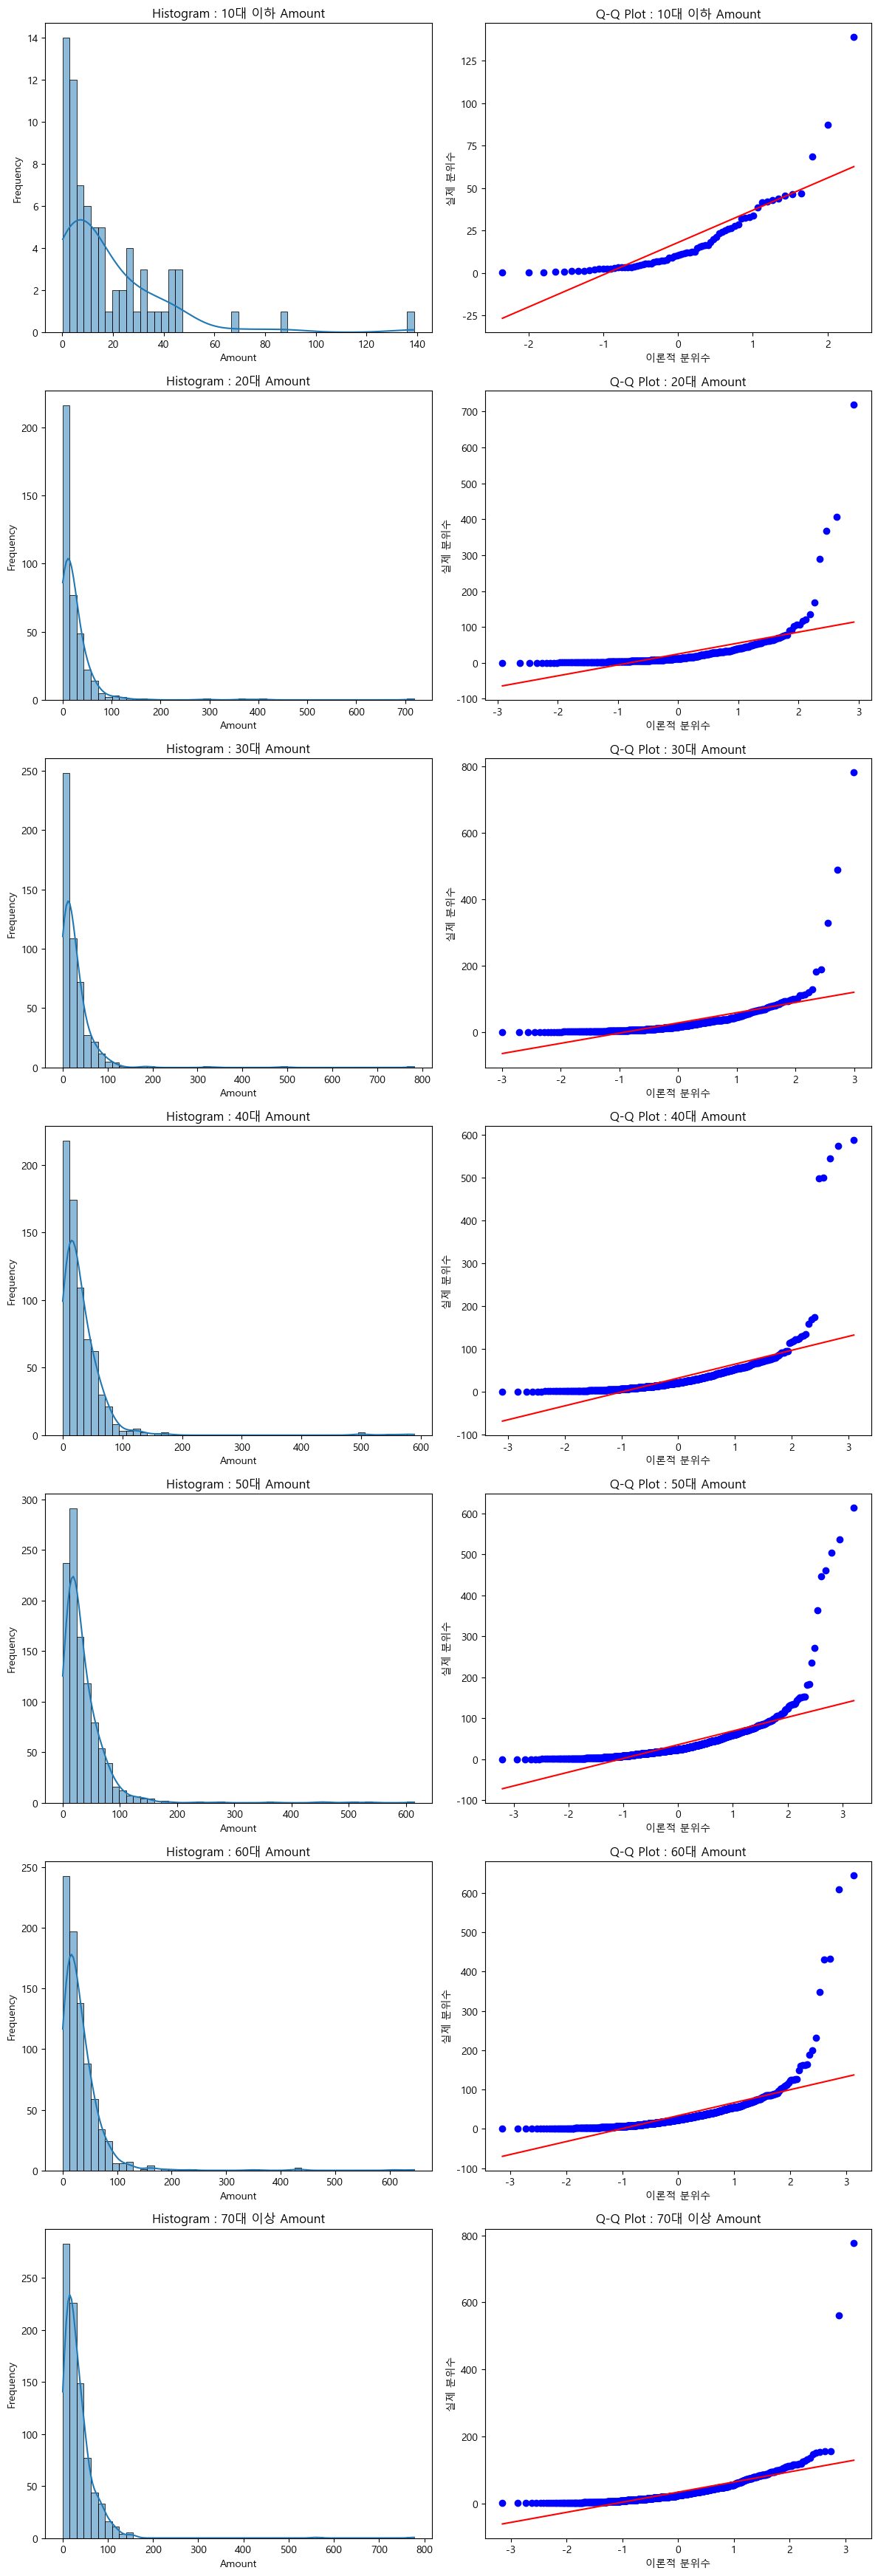

[가설검정] Kruskal-Wallis H 검정
검정 통계량(H) : 149.4008
p-value : 1.0358e-29
결론: p-value(1.0358e-29)가 0.05보다 작으므로 귀무가설 기각
해석: 연령대별 평균 결제 금액에는 통계적으로 유의미한 차이가 있다.
[사후검정] Dunn's Test
전체 연령대 간 1:1 p-value 교차표


,10대 이하,20대,30대,40대,50대,60대,70대 이상
10대 이하,1.000000e+00,1.000000e+00,1.673001e-01,2.677712e-04,7.090855e-08,9.351957e-06,7.072221e-07
20대,1.000000e+00,1.000000e+00,2.406577e-01,5.853240e-08,2.277583e-19,3.206356e-12,1.324304e-15
30대,1.673001e-01,2.406577e-01,1.000000e+00,1.029165e-02,4.475633e-11,1.261453e-05,3.406431e-08
40대,2.677712e-04,5.853240e-08,1.029165e-02,1.000000e+00,5.108545e-03,1.000000e+00,1.533240e-01
50대,7.090855e-08,2.277583e-19,4.475633e-11,5.108545e-03,1.000000e+00,7.454772e-01,1.000000e+00
60대,9.351957e-06,3.206356e-12,1.261453e-05,1.000000e+00,7.454772e-01,1.000000e+00,1.000000e+00
70대 이상,7.072221e-07,1.324304e-15,3.406431e-08,1.533240e-01,1.000000e+00,1.000000e+00,1.000000e+00


통계적으로 유의미한 결제 금액 차이가 있는 연령대 조합


,Group 1,Group 2,p-value
0,20대,50대,2.277583e-19
1,20대,70대 이상,1.324304e-15
2,20대,60대,3.206356e-12
3,30대,50대,4.475633e-11
4,30대,70대 이상,3.406431e-08
5,20대,40대,5.853240e-08
6,10대 이하,50대,7.090855e-08
7,10대 이하,70대 이상,7.072221e-07
8,10대 이하,60대,9.351957e-06
9,30대,60대,1.261453e-05


[효과크기] η²_H
효과크기(η²_H): 0.0327
해석: 효과크기 수준은 Small (작은 차이)


In [17]:
# 연령대에 따른 평균 결제 금액 비교

df_age = final_paid_df.dropna(subset=['amount', 'age_group'])
df_age = df_age[df_age['age_group'] != 'Unknown'] # age_group에 Unknown 제외.
age_groups = sorted(df_age['age_group'].unique()) # 연령대 오름차순 정렬

for age in age_groups:
    age_amount = df_age[df_age['age_group'] == age]['amount']
    print(f" - {age} 인원 수 : {len(age_amount)}명 / 평균 결제액 : ${age_amount.mean():.2f}")

# 정규성 검정(Shapiro-Wilk)
print("="*80)
print("[정규성 검정]")
for age in age_groups:
    age_amount = df_age[df_age['age_group']==age]['amount']
    stat, p_norm = stats.shapiro(age_amount)

    print(f"{age} p-value : {p_norm:.4e}")
    if p_norm<0.05:
        print(f"결론: p-value({p_norm:.4e})가 0.05보다 작으므로 귀무가설 기각")
        print(f"해석: {age}의 결제 금액은 정규분포를 따르지 않는다.\n")
    else:
        print(f"결론: p-value({p_norm:.4e})가 0.05이상이므로 귀무가설 기각 실패")
        print(f"해석: {age}의 결제 금액은 정규분포를 따른다.\n")

print("="*80)
print("[데이터 분포 시각화: Histogram & Q-Q Plot]")
n_groups = len(age_groups)
plt.figure(figsize=(12, 5 * n_groups))

for i, age in enumerate(age_groups):
    age_amount = df_age[df_age['age_group'] == age]['amount']
    
    # 1. 히스토그램 (좌측)
    plt.subplot(n_groups, 2, (i * 2) + 1)
    sns.histplot(age_amount, kde=True, bins=50)
    plt.title(f"Histogram : {age} Amount")
    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    
    # 2. Q-Q Plot (우측)
    plt.subplot(n_groups, 2, (i * 2) + 2)
    stats.probplot(age_amount, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot : {age} Amount")
    plt.xlabel("이론적 분위수")
    plt.ylabel("실제 분위수")

plt.tight_layout()
plt.show()
# 전체적으로 우측으로 꼬리가 긴(Right-skewed) 비대칭 형태


# 가설 검정(Kruskal-Wallis H 검정)
print("="*80)
print("[가설검정] Kruskal-Wallis H 검정")

kw_result = pg.kruskal(data=df_age, dv='amount', between='age_group')
p_val_kw = kw_result['p_unc'].values[0]
stat_kw = kw_result['H'].values[0]

print(f"검정 통계량(H) : {stat_kw:.4f}")
print(f"p-value : {p_val_kw:.4e}")

if p_val_kw < 0.05:
    print(f"결론: p-value({p_val_kw:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 연령대별 평균 결제 금액에는 통계적으로 유의미한 차이가 있다.")
else: 
    print(f"결론: p-value({p_val_kw:.4e})가 0.05이상이므로 귀무가설 기각 실패")
    print("해석: 연령대별 평균 결제 금액에는 통계적으로 유의미하지 않다.")

# 사후 검정(Dunn's Test)
print("="*80)
print("[사후검정] Dunn's Test")
if p_val_kw < 0.05:
    dunn_result = sp.posthoc_dunn(df_age, val_col='amount', group_col='age_group', p_adjust='bonferroni')
    print("전체 연령대 간 1:1 p-value 교차표")
    display(dunn_result)

    print("통계적으로 유의미한 결제 금액 차이가 있는 연령대 조합")
    # 행과 열을 풀어서(unstack) 보기 편한 형태로 변환
    dunn_melted = dunn_result.unstack().reset_index()
    dunn_melted.columns = ['Group 1', 'Group 2', 'p-value']
    
    # 중복되는 쌍(A-B, B-A)과 자기 자신(A-A) 제외, p-value 0.05 미만 필터링
    sig_pairs = dunn_melted[(dunn_melted['Group 1'] < dunn_melted['Group 2']) & (dunn_melted['p-value'] < 0.05)]
    
    if len(sig_pairs) > 0:
        display(sig_pairs.sort_values('p-value').reset_index(drop=True))
    else:
        print("전체적인 차이는 있으나, 1:1로 쪼갰을 때 명확히 튀는 조합은 잡히지 않음")
else:
    print("해석: Kruskal-Wallis 검정에서 유의미한 차이가 없으므로 사후 검정을 진행하지 않는다.")

# 효과 크기(η²_H)
print("="*80)
print("[효과크기] η²_H")
if p_val_kw < 0.05:
    H = stat_kw
    k = len(age_groups)
    N = len(df_age)

    eta_sq_H = (H - k + 1) / (N - k)
    print(f"효과크기(η²_H): {eta_sq_H:.4f}")

    #효과크기 해석
    if eta_sq_H < 0.01:
        print("해석: 효과크기 수준은 Very Small (통계적으로 차이는 있으나, 실질적인 차이는 거의 없음)")
    elif eta_sq_H < 0.06:
        print("해석: 효과크기 수준은 Small (작은 차이)")
    elif eta_sq_H < 0.14:
        print("해석: 효과크기 수준은 Medium (중간 수준의 차이)")
    else:
        print("해석: 효과크기 수준은 Large (큰 차이)")
else:
    print("해석: Kruskal-Wallis 검정에서 유의미한 차이가 없으므로 효과크기를 계산하지 않는다.")

# 최종 인사이트
- 연령대가 결제 금액 차이에 통계적으로 유의한 영향을 미치지만, 전체적인 영향력 자체는 크지 않다.
- 젊은 청년층과 중장년층의 평균 결제 금액의 차이가 있음을 확인할 수 있다. 따라서, 두 그룹으로 나누어서 마케팅 전략을 생각하는 것도 좋을 것 같다.

[소득 수준별 평균 결제 금액 EDA]
 - 4만 미만 인원 수 : 654명 / 평균 결제액 : $16.34
 - 4만~6만 인원 수 : 1506명 / 평균 결제액 : $23.50
 - 6만~8만 인원 수 : 1382명 / 평균 결제액 : $37.27
 - 8만~10만 인원 수 : 677명 / 평균 결제액 : $49.61
 - 10만 이상 인원 수 : 176명 / 평균 결제액 : $54.59

[정규성 검정]
4만 미만 p-value : 1.5810e-39
결론: p-value(1.5810e-39)가 0.05보다 작으므로 귀무가설 기각
해석: 4만 미만 그룹의 결제 금액은 정규분포를 따르지 않는다.

4만~6만 p-value : 5.8126e-54
결론: p-value(5.8126e-54)가 0.05보다 작으므로 귀무가설 기각
해석: 4만~6만 그룹의 결제 금액은 정규분포를 따르지 않는다.

6만~8만 p-value : 4.3091e-54
결론: p-value(4.3091e-54)가 0.05보다 작으므로 귀무가설 기각
해석: 6만~8만 그룹의 결제 금액은 정규분포를 따르지 않는다.

8만~10만 p-value : 2.1301e-41
결론: p-value(2.1301e-41)가 0.05보다 작으므로 귀무가설 기각
해석: 8만~10만 그룹의 결제 금액은 정규분포를 따르지 않는다.

10만 이상 p-value : 1.1354e-21
결론: p-value(1.1354e-21)가 0.05보다 작으므로 귀무가설 기각
해석: 10만 이상 그룹의 결제 금액은 정규분포를 따르지 않는다.

[데이터 분포 시각화: Histogram & Q-Q Plot]


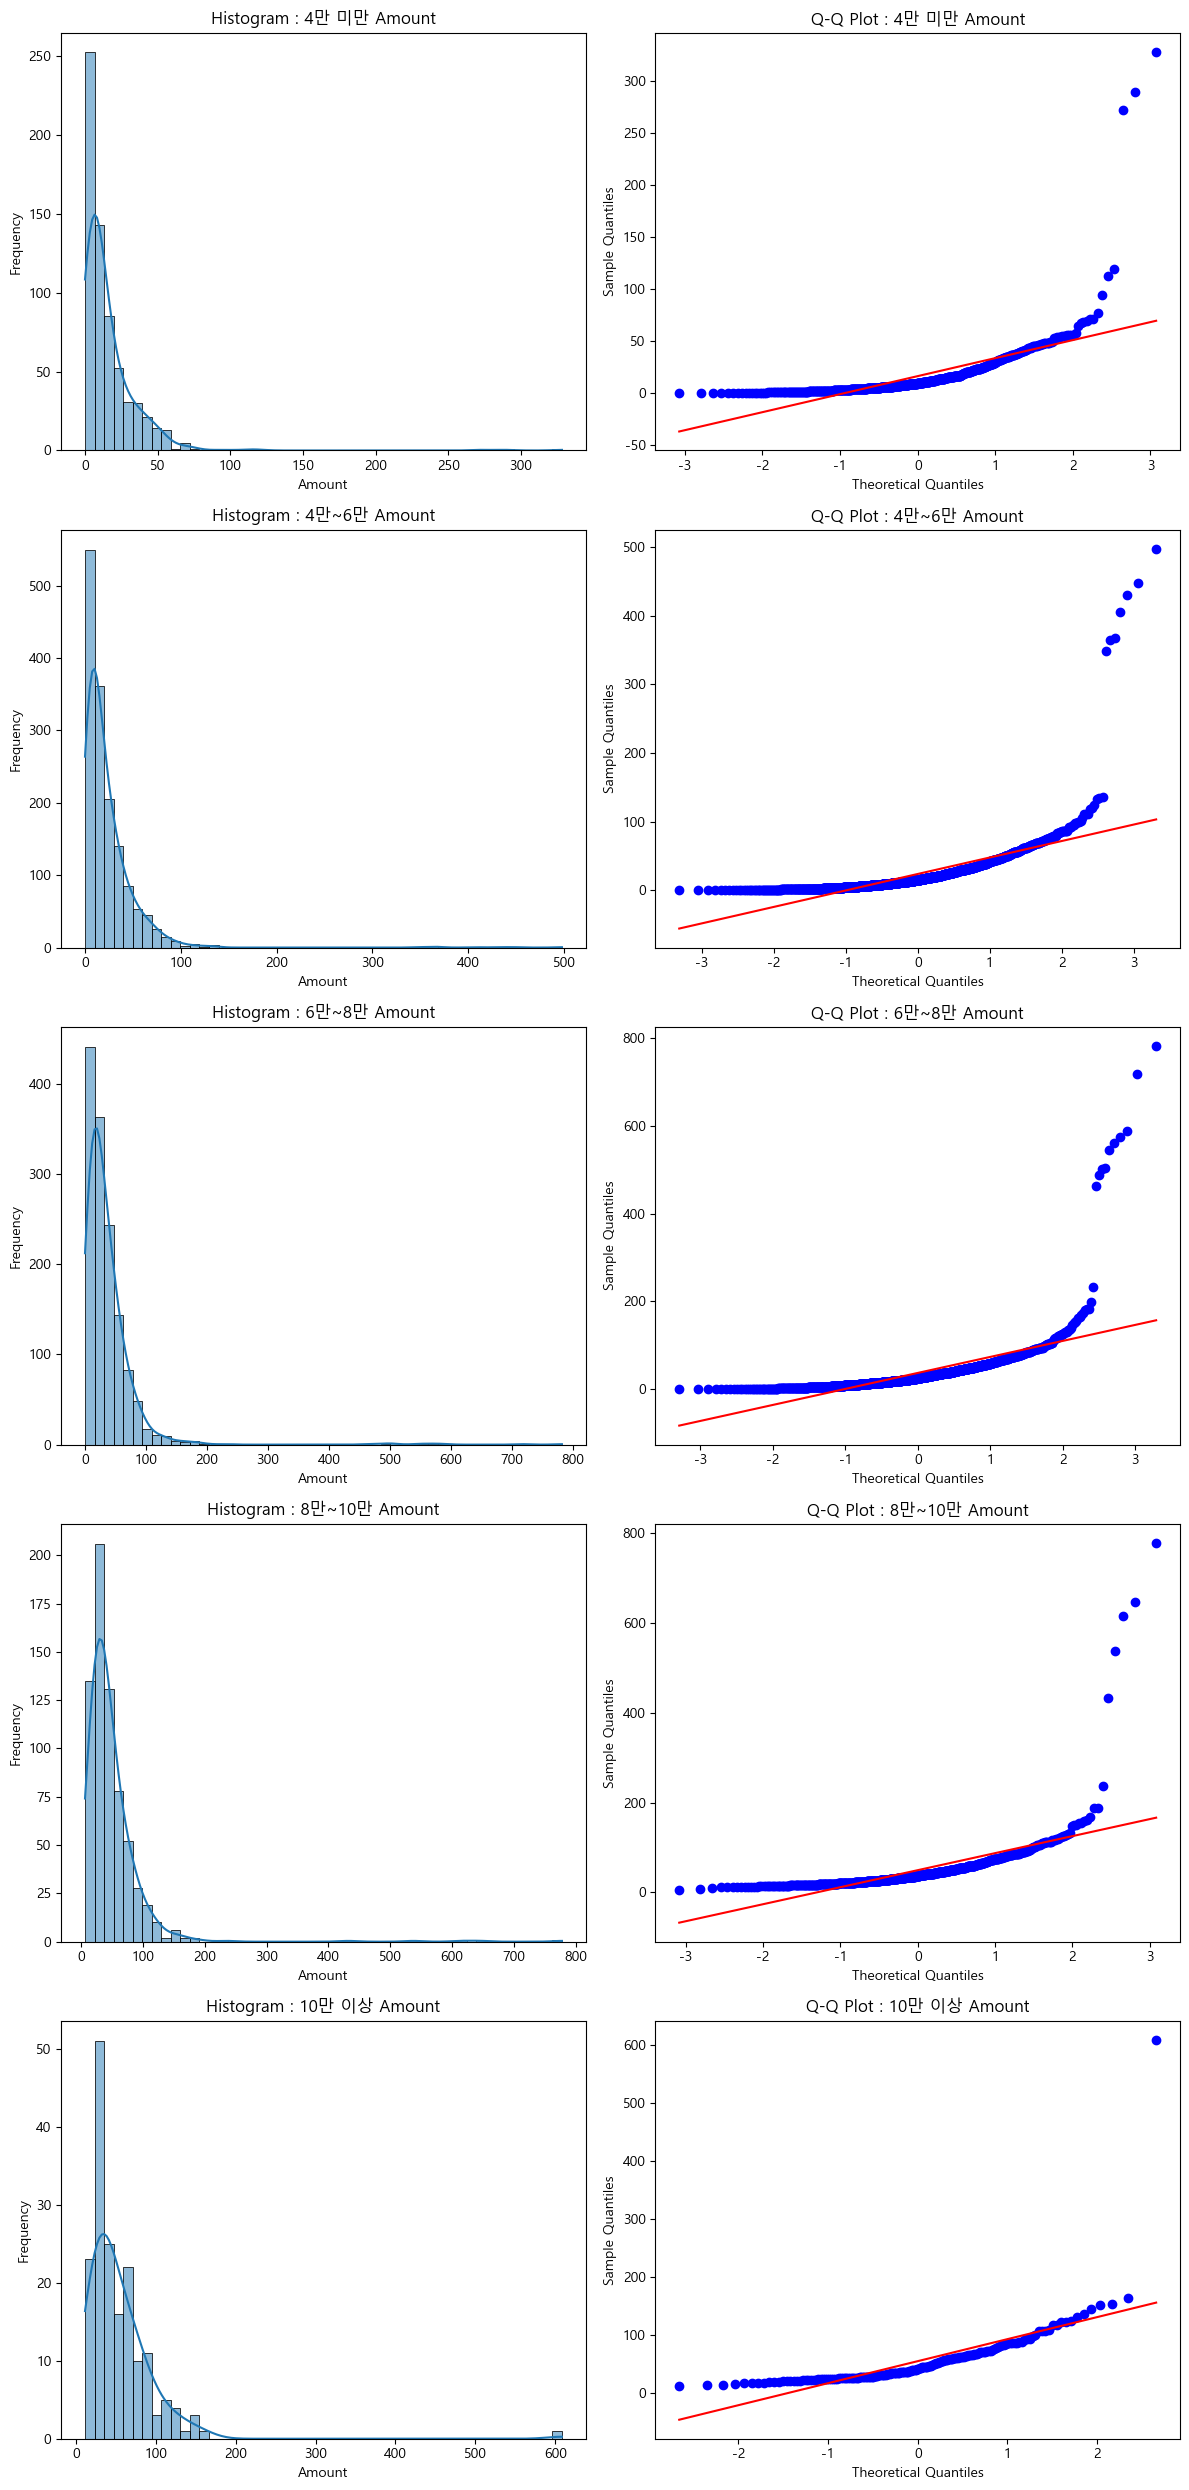

[가설검정] Kruskal-Wallis H 검정
검정 통계량(H) : 879.2597
p-value : 5.1910e-189
결론: p-value(5.1910e-189)가 0.05보다 작으므로 귀무가설 기각
해석: 소득 수준별 평균 결제 금액에는 통계적으로 유의미한 차이가 있다.
[사후검정] Dunn's Test
전체 소득 수준 간 1:1 p-value 교차표


,10만 이상,4만 미만,4만~6만,6만~8만,8만~10만
10만 이상,1.000000e+00,1.766774e-64,1.755418e-44,7.741938e-15,1.000000e+00
4만 미만,1.766774e-64,1.000000e+00,4.793967e-11,1.007228e-63,6.060103e-126
4만~6만,1.755418e-44,4.793967e-11,1.000000e+00,2.173330e-37,1.211595e-100
6만~8만,7.741938e-15,1.007228e-63,2.173330e-37,1.000000e+00,2.619916e-26
8만~10만,1.000000e+00,6.060103e-126,1.211595e-100,2.619916e-26,1.000000e+00



통계적으로 유의미한 결제 금액 차이가 있는 소득 수준 조합


,Group 1,Group 2,p-value
0,4만 미만,8만~10만,6.060103e-126
1,4만~6만,8만~10만,1.211595e-100
2,10만 이상,4만 미만,1.766774e-64
3,4만 미만,6만~8만,1.007228e-63
4,10만 이상,4만~6만,1.755418e-44
5,4만~6만,6만~8만,2.173330e-37
6,6만~8만,8만~10만,2.619916e-26
7,10만 이상,6만~8만,7.741938e-15
8,4만 미만,4만~6만,4.793967e-11


[효과크기] η²_H
효과크기(η²_H): 0.1994
해석: 효과크기 수준은 Large (큰 차이)


In [19]:
# 소득 수준(income_group)에 따른 평균 결제 금액(amount) 비교

# 데이터 준비 (결측치 및 Unknown 제거)
df_inc = final_paid_df.dropna(subset=['amount', 'income_group'])
df_inc = df_inc[df_inc['income_group'] != 'Unknown'] # Unknown 데이터가 있다면 제외
income_groups = ['4만 미만', '4만~6만', '6만~8만', '8만~10만', '10만 이상']

print("[소득 수준별 평균 결제 금액 EDA]")
for inc in income_groups:
    inc_amount = df_inc[df_inc['income_group'] == inc]['amount']
    print(f" - {inc} 인원 수 : {len(inc_amount)}명 / 평균 결제액 : ${inc_amount.mean():.2f}")

# 정규성 검정(Shapiro-Wilk)
print("\n" + "="*80)
print("[정규성 검정]")
for inc in income_groups:
    inc_amount = df_inc[df_inc['income_group']==inc]['amount']
    stat, p_norm = stats.shapiro(inc_amount)

    print(f"{inc} p-value : {p_norm:.4e}")
    if p_norm < 0.05:
        print(f"결론: p-value({p_norm:.4e})가 0.05보다 작으므로 귀무가설 기각")
        print(f"해석: {inc} 그룹의 결제 금액은 정규분포를 따르지 않는다.\n")
    else:
        print(f"결론: p-value({p_norm:.4e})가 0.05이상이므로 귀무가설 기각 실패")
        print(f"해석: {inc} 그룹의 결제 금액은 정규분포를 따른다.\n")

# 데이터 분포 시각화: Histogram & Q-Q Plot
print("="*80)
print("[데이터 분포 시각화: Histogram & Q-Q Plot]")
n_groups = len(income_groups)
plt.figure(figsize=(12, 5 * n_groups))

for i, inc in enumerate(income_groups):
    inc_amount = df_inc[df_inc['income_group'] == inc]['amount']
    
    # 히스토그램 (좌측)
    plt.subplot(n_groups, 2, (i * 2) + 1)
    sns.histplot(inc_amount, kde=True, bins=50)
    plt.title(f"Histogram : {inc} Amount")
    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    
    # Q-Q Plot (우측)
    plt.subplot(n_groups, 2, (i * 2) + 2)
    stats.probplot(inc_amount, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot : {inc} Amount")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

# 가설 검정(Kruskal-Wallis H 검정)
print("="*80)
print("[가설검정] Kruskal-Wallis H 검정")

kw_result = pg.kruskal(data=df_inc, dv='amount', between='income_group')
p_val_kw = kw_result['p_unc'].values[0]
stat_kw = kw_result['H'].values[0]

print(f"검정 통계량(H) : {stat_kw:.4f}")
print(f"p-value : {p_val_kw:.4e}")

if p_val_kw < 0.05:
    print(f"결론: p-value({p_val_kw:.4e})가 0.05보다 작으므로 귀무가설 기각")
    print("해석: 소득 수준별 평균 결제 금액에는 통계적으로 유의미한 차이가 있다.")
else: 
    print(f"결론: p-value({p_val_kw:.4e})가 0.05이상이므로 귀무가설 기각 실패")
    print("해석: 소득 수준별 평균 결제 금액에는 통계적으로 유의미한 차이가 없다.")

# 사후 검정(Dunn's Test)
print("="*80)
print("[사후검정] Dunn's Test")
if p_val_kw < 0.05:
    dunn_result = sp.posthoc_dunn(df_inc, val_col='amount', group_col='income_group', p_adjust='bonferroni')
    print("전체 소득 수준 간 1:1 p-value 교차표")
    display(dunn_result)

    print("\n통계적으로 유의미한 결제 금액 차이가 있는 소득 수준 조합")
    dunn_melted = dunn_result.unstack().reset_index()
    dunn_melted.columns = ['Group 1', 'Group 2', 'p-value']
    
    sig_pairs = dunn_melted[(dunn_melted['Group 1'] < dunn_melted['Group 2']) & (dunn_melted['p-value'] < 0.05)]
    
    if len(sig_pairs) > 0:
        display(sig_pairs.sort_values('p-value').reset_index(drop=True))
    else:
        print("전체적인 차이는 있으나, 1:1로 쪼갰을 때 명확히 튀는 조합은 잡히지 않음")
else:
    print("해석: Kruskal-Wallis 검정에서 유의미한 차이가 없으므로 사후 검정을 진행하지 않는다.")

# 효과 크기(η²_H)
print("="*80)
print("[효과크기] η²_H")
if p_val_kw < 0.05:
    H = stat_kw
    k = len(income_groups)
    N = len(df_inc)

    eta_sq_H = (H - k + 1) / (N - k) 
    print(f"효과크기(η²_H): {eta_sq_H:.4f}")

    if eta_sq_H < 0.01:
        print("해석: 효과크기 수준은 Very Small (통계적으로 차이는 있으나, 실질적인 차이는 거의 없음)")
    elif eta_sq_H < 0.06:
        print("해석: 효과크기 수준은 Small (작은 차이)")
    elif eta_sq_H < 0.14:
        print("해석: 효과크기 수준은 Medium (중간 수준의 차이)")
    else:
        print("해석: 효과크기 수준은 Large (큰 차이)")
else:
    print("해석: Kruskal-Wallis 검정에서 유의미한 차이가 없으므로 효과크기를 계산하지 않는다.")

# 최종 인사이트
- 소득수준이 결제 금액차이에 통계적으로 유의한 영향을 미치고, 전체적인 영향력 자체도 크다.
- 소득수준을 핵심 변수로 생각할 수 있을 것같다. 소득 수준에 따른 마케팅 전략을 고려해봐야 한다.